# 11.1

## tourism

In [6]:
import pandas as pd

state_abbrev = {
    "New South Wales": "NSW",
    "Northern Territory": "NT",
    "Queensland": "QLD",
    "South Australia": "SA",
    "Tasmania": "TAS",
    "Victoria": "VIC",
    "Western Australia": "WA",
}
aus_tourism = (
    pd.read_csv("../data/fpp3/aus_tourism.csv", parse_dates=[1])
    .assign(
        split=lambda x: x["unique_id"].str.split('-'),
        Country="Australia",
        Region=lambda x: x["split"].str[0],
        State=lambda x: x["split"].str[1].replace(state_abbrev),
        Purpose=lambda x: x["split"].str[2],
    )
    .drop(columns="split")
)

In [4]:
from hierarchicalforecast.utils import aggregate, HierarchicalPlot

spec = [
    ["Country"],
    ["Country", "State"],
    ["Country", "State", "Region"],
]
Y_df, S_df, tags = aggregate(
    df=aus_tourism.drop(columns=["unique_id"]), spec=spec)
Y_df

,unique_id,ds,y
0,Australia,1998-03-31,23182.197269
1,Australia,1998-06-30,20323.380067
2,Australia,1998-09-30,19826.640511
3,Australia,1998-12-31,20830.129891
4,Australia,1999-03-31,22087.353380
...,...,...,...
6795,Australia/WA/Experience Perth,2016-12-31,1058.296314
6796,Australia/WA/Experience Perth,2017-03-31,956.573673
6797,Australia/WA/Experience Perth,2017-06-30,908.335190
6798,Australia/WA/Experience Perth,2017-09-30,1006.268684


In [7]:
S_df.iloc[:, :5]

,unique_id,Australia/ACT/Canberra,Australia/NSW/Blue Mountains,Australia/NSW/Capital Country,Australia/NSW/Central Coast
0,Australia,1.0,1.0,1.0,1.0
1,Australia/ACT,1.0,0.0,0.0,0.0
2,Australia/NSW,0.0,1.0,1.0,1.0
3,Australia/NT,0.0,0.0,0.0,0.0
4,Australia/QLD,0.0,0.0,0.0,0.0
...,...,...,...,...,...
80,Australia/WA/Australia's Coral Coast,0.0,0.0,0.0,0.0
81,Australia/WA/Australia's Golden Outback,0.0,0.0,0.0,0.0
82,Australia/WA/Australia's North West,0.0,0.0,0.0,0.0
83,Australia/WA/Australia's South West,0.0,0.0,0.0,0.0


In [8]:
for (tag, unique_ids) in tags.items():
    print(tag)
    print(unique_ids, end='\n\n')

Country
['Australia']

Country/State
['Australia/ACT' 'Australia/NSW' 'Australia/NT' 'Australia/QLD'
 'Australia/SA' 'Australia/TAS' 'Australia/VIC' 'Australia/WA']

Country/State/Region
['Australia/ACT/Canberra' 'Australia/NSW/Blue Mountains'
 'Australia/NSW/Capital Country' 'Australia/NSW/Central Coast'
 'Australia/NSW/Central NSW' 'Australia/NSW/Hunter'
 'Australia/NSW/New England North West' 'Australia/NSW/North Coast NSW'
 'Australia/NSW/Outback NSW' 'Australia/NSW/Riverina'
 'Australia/NSW/Snowy Mountains' 'Australia/NSW/South Coast'
 'Australia/NSW/Sydney' 'Australia/NSW/The Murray'
 'Australia/NT/Alice Springs' 'Australia/NT/Barkly' 'Australia/NT/Darwin'
 'Australia/NT/Kakadu Arnhem' 'Australia/NT/Katherine Daly'
 'Australia/NT/Lasseter' 'Australia/NT/MacDonnell'
 'Australia/QLD/Brisbane' 'Australia/QLD/Bundaberg'
 'Australia/QLD/Central Queensland' 'Australia/QLD/Darling Downs'
 'Australia/QLD/Fraser Coast' 'Australia/QLD/Gold Coast'
 'Australia/QLD/Mackay' 'Australia/QLD/Nort

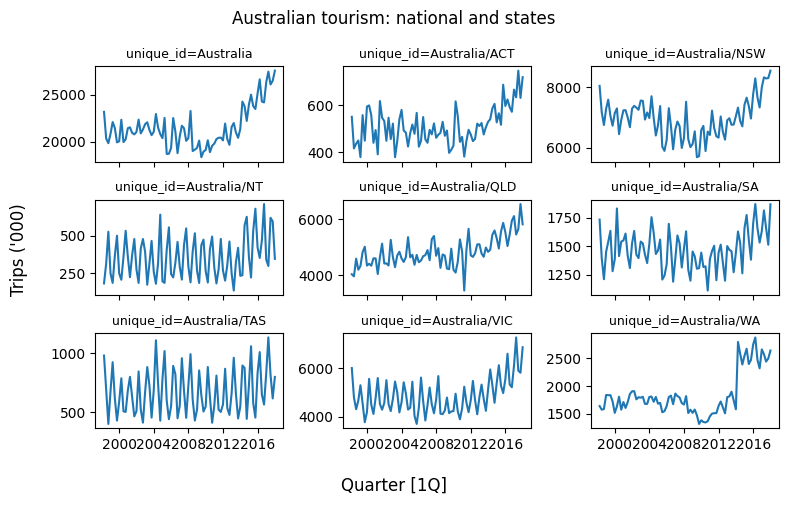

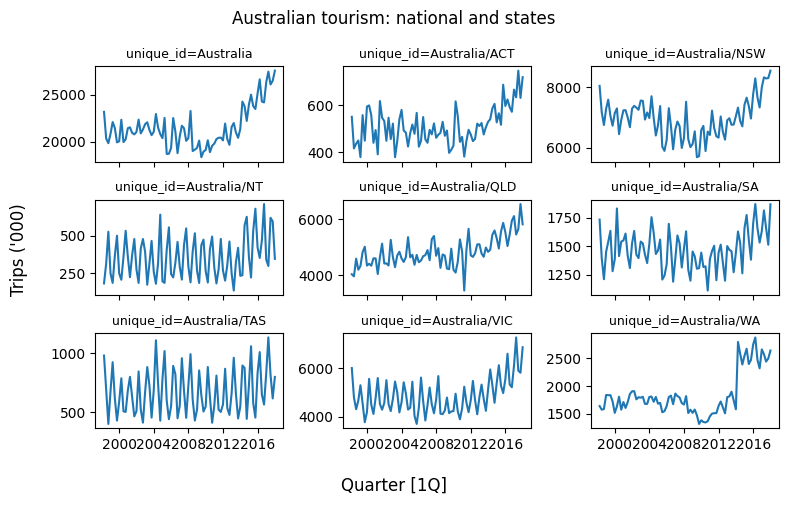

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(8, 5), sharex=True)
plot_tags = [*tags["Country"], *tags["Country/State"]]
plot_Y_df = Y_df[Y_df["unique_id"].isin(plot_tags)]

for ax, uid in zip(axes.flat, plot_tags):
    s = plot_Y_df.loc[plot_Y_df["unique_id"] == uid]
    ax.plot(s["ds"], s["y"])
    ax.set_title(f"unique_id={uid}", fontsize=9)

fig.suptitle("Australian tourism: national and states", fontsize=12)
fig.supylabel("Trips ('000)")
fig.supxlabel("Quarter [1Q]")
fig.tight_layout()
fig

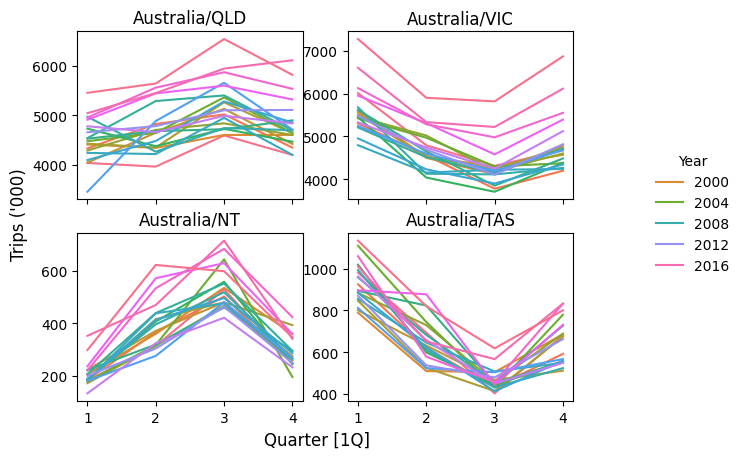

In [14]:
import seaborn as sns
from matplotlib.ticker import MaxNLocator

states = ["Australia/QLD", "Australia/VIC", "Australia/NT", "Australia/TAS"]
tourism_df = Y_df[Y_df["unique_id"].isin(states)].assign(
  year=lambda x: x["ds"].dt.year, quarter=lambda x: x["ds"].dt.quarter
)
fig, axes = plt.subplots(2, 2, sharex=True)
for ax, state in zip(axes.flat, states):
    state_df = tourism_df.loc[lambda x: x["unique_id"] == state]
    sns.lineplot(data=state_df, x="quarter", y="y",
        hue="year", palette="husl", ax=ax)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set(title=state, xlabel="", ylabel="")
    ax.get_legend().remove()

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels, title="Year",
    bbox_to_anchor=(1.02, 0.5), loc="center left",
    borderaxespad=0, frameon=False)
fig.supylabel("Trips ('000)")
fig.supxlabel("Quarter [1Q]")
plt.show()

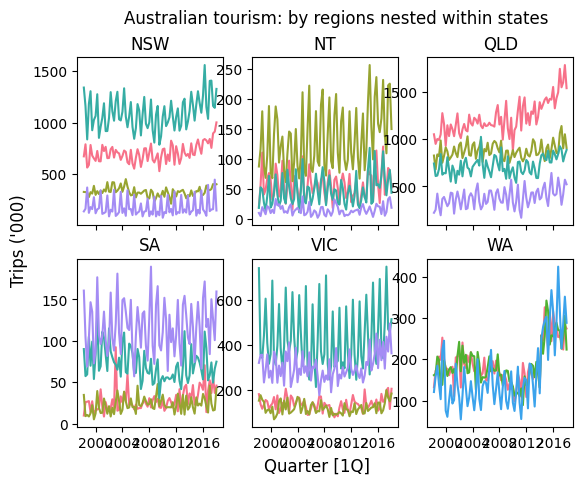

In [15]:
plot_regions = [
  "North Coast NSW", "Snowy Mountains", "Hunter",
  "New England North West", "Alice Springs", "Darwin",
  "Kakadu Arnhem", "MacDonnell", "Brisbane",
  "Gold Coast", "Northern Outback", "Sunshine Coast",
  "Tropical North Queensland", "Adelaide Hills", "Murraylands",
  "Yorke Peninsula", "Kangaroo Island", "Ballarat",
  "Great Ocean Road", "High Country", "Goulburn", "Australia's Coral Coast",
  "Australia's Golden Outback", "Australia's North West",
  "Australia's North West",
]
aus_tourism_rq = aus_tourism.query("Region in @plot_regions")
plot_states = ["NSW", "NT", "QLD", "SA", "VIC", "WA"]

fig, axs = plt.subplots(2, 3, sharex=True)
for state, ax in zip(plot_states, axs.flatten()):
    plot_state = (
        aus_tourism_rq.query("State == @state")
        .groupby(["Region", "State", "ds"])
        .sum(numeric_only=True)
        .reset_index()
    )
    sns.lineplot(data=plot_state, x="ds", y="y",
        hue="Region", palette="husl", ax=ax, legend=False)
    ax.set(title=state, xlabel="", ylabel="")
fig.supylabel("Trips ('000)")
fig.supxlabel("Quarter [1Q]")
fig.suptitle("Australian tourism: by regions nested within states", x=.53)
plt.show()

## prison

In [20]:
prison = pd.read_csv("../data/fpp3/prison.csv", index_col=0).assign(
    ds=lambda x: pd.PeriodIndex(x["ds"], freq="Q").to_timestamp(),
    Country="Australia",
)

In [21]:
spec = [
    ["Country"],
    ["Country", "State"],
    ["Country", "Gender"],
    ["Country", "Legal"],
    ["Country", "Indigenous"],
    ["Country", "State", "Gender"],
    ["Country", "State", "Legal"],
    ["Country", "Legal", "Gender"],
    ["Country", "State", "Legal", "Gender"],
    ["Country", "State", "Gender", "Legal", "Indigenous"],
]
Y_df, S_df, tags = aggregate(df=prison, spec=spec)

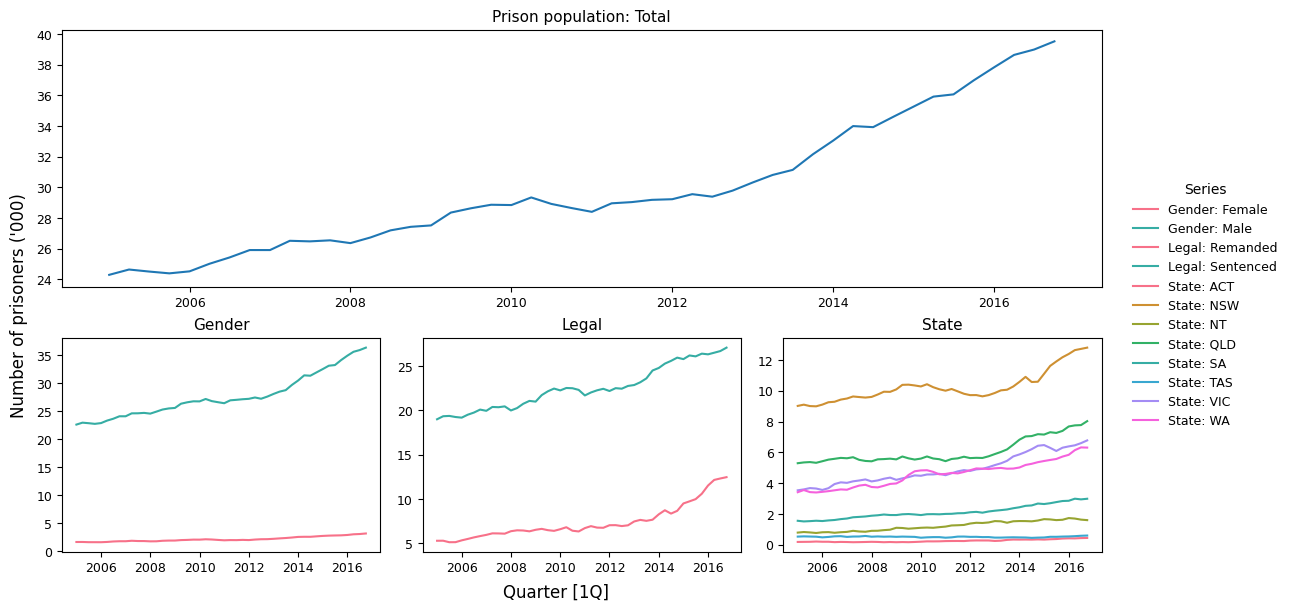

In [25]:
import matplotlib.dates as mdates

Y_df_plot = Y_df.assign(y=Y_df["y"] / 1e3).set_index("unique_id")
key_columns = ["Gender", "Legal", "State"]
mosaic = [3 * ["Country"], key_columns]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(11, 6),
    layout="constrained",   # auto-adjusts spacing
    gridspec_kw={"height_ratios": [1.2, 1]},
)

# Plot total
df = Y_df_plot.loc["Australia"]
ax = axes["Country"]
sns.lineplot(data=df, x="ds", y="y", ax=ax)
ax.set(title="Prison population: Total", xlabel="", ylabel="")

# Plot gender, legal, state
all_handles, all_labels = [], []
for key_column in key_columns:
    labels = prison[key_column].unique()
    legend_labels = [f"{key_column}: {label}" for label in labels]
    label_data = pd.concat([
        Y_df_plot.loc[f"Australia/{label}"]
        for label in labels
    ], keys=legend_labels).reset_index(level=0)

    ax = axes[key_column]
    sns.lineplot(
        data=label_data, x="ds", y="y",
        hue="level_0", palette="husl", ax=ax,
    )
    ax.set(title=key_column, xlabel="", ylabel="")
    ax.get_legend().remove()
    handles, labels = ax.get_legend_handles_labels()
    all_handles.extend(handles)
    all_labels.extend(labels)

# Shared labels (once, not per-axis)
fig.supylabel("Number of prisoners ('000)")
fig.supxlabel("Quarter [1Q]")

# Cleaner x ticks on all panels
for ax in axes.values():
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=0, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.title.set_fontsize(11)

fig.legend(
    all_handles, all_labels,
    title="Series",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    borderaxespad=0,
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)


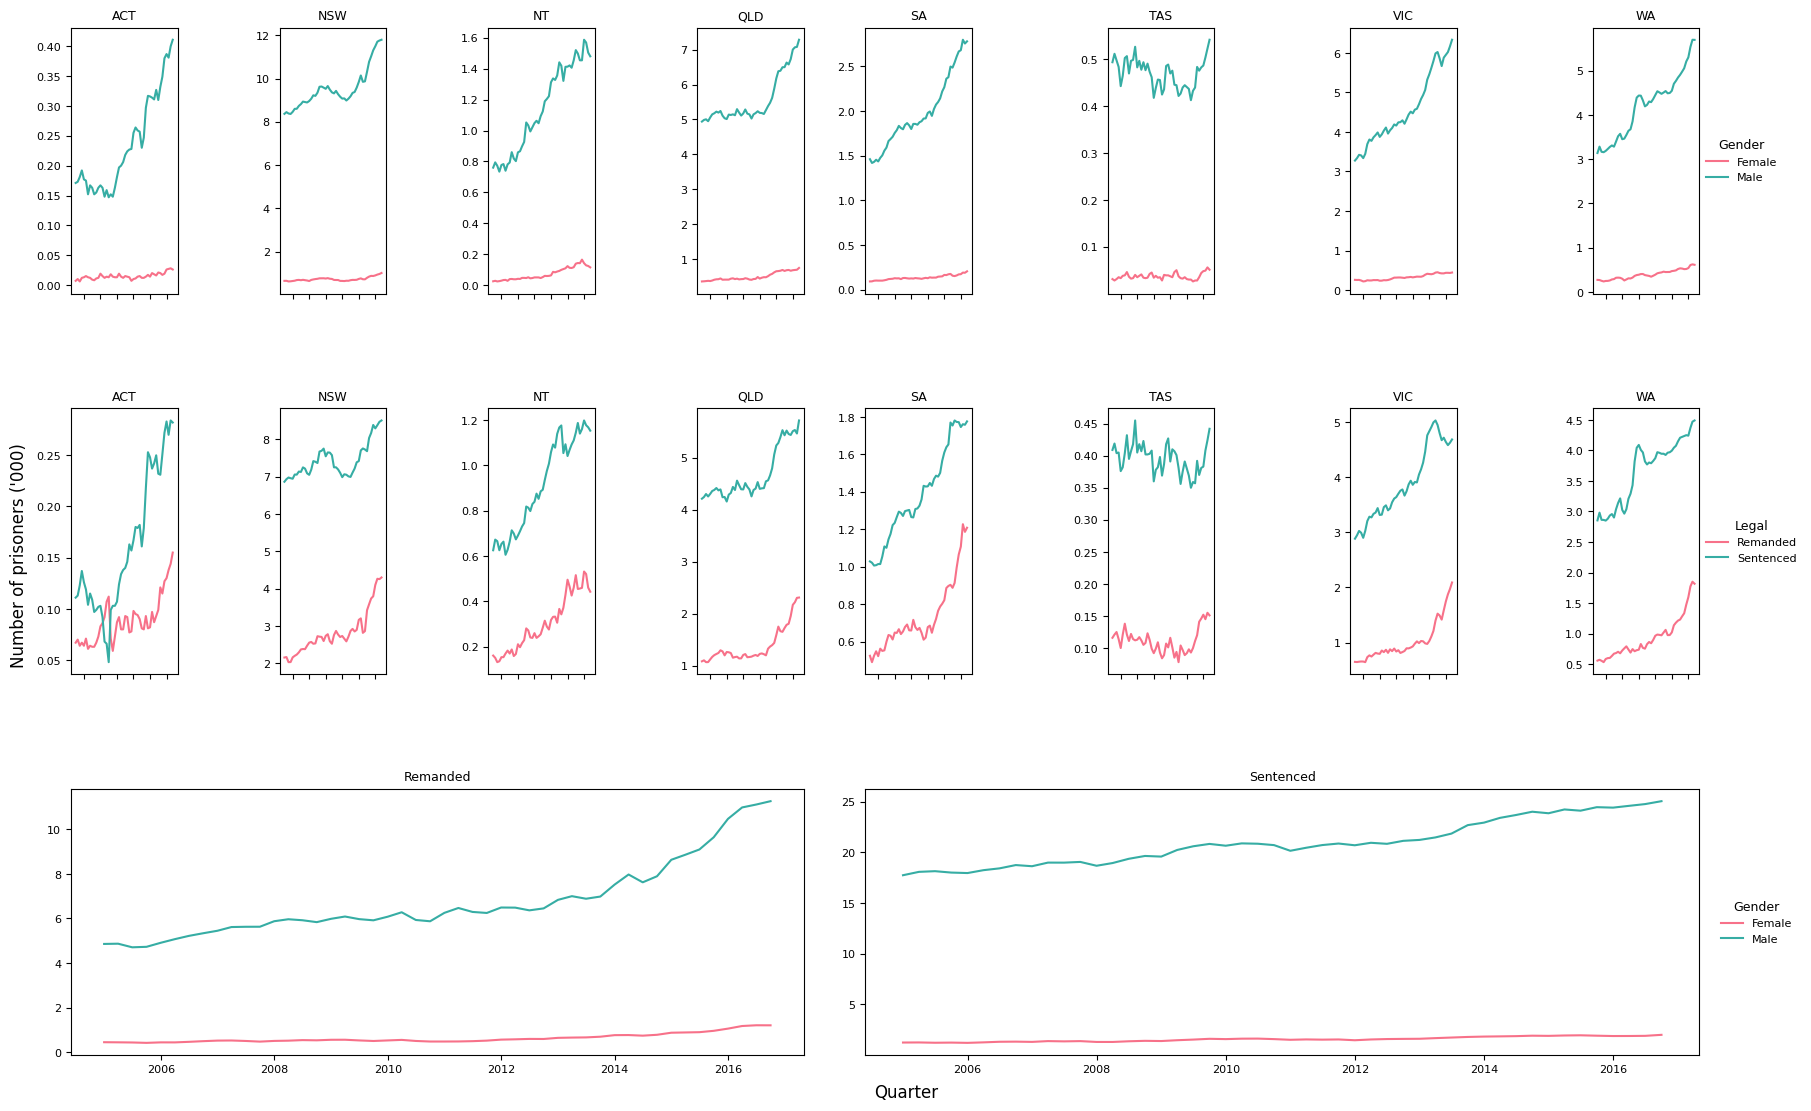

In [29]:
import matplotlib.dates as mdates

Y_df_plot = Y_df.assign(y=Y_df["y"] / 1e3).set_index("unique_id")
states = list(tags["Country/State"])
genders = prison["Gender"].unique()
legals = prison["Legal"].unique()

state_gender = [f"{state} Gender" for state in states]
state_legal = [f"{state} Legal" for state in states]
legal_gender = 4 * ["Remanded Gender"] + 4 * ["Sentenced Gender"]
mosaic = [state_gender, state_legal, legal_gender]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(18, 11),
    sharex=True,
    layout="constrained",
    gridspec_kw={"hspace": 0.25, "wspace": 0.15},
)

# Plot state/gender and state/legal
for key_column in ("Gender", "Legal"):
    for i, state in enumerate(states):
        labels = prison[key_column].unique()
        label_data = pd.concat([
            Y_df_plot.loc[f"{state}/{label}"]
            for label in labels
        ], keys=labels).reset_index(level=0)

        ax = axes[f"{state} {key_column}"]
        sns.lineplot(
            data=label_data, x="ds", y="y",
            hue="level_0", palette="husl", ax=ax,
        )
        ax.set(title=state.split("/")[-1], xlabel="", ylabel="")
        if i == len(states) - 1:
            ax.legend(
                title=key_column,
                bbox_to_anchor=(1.02, 0.5),
                loc="center left",
                borderaxespad=0,
                frameon=False,
                fontsize=8,
                title_fontsize=9,
            )
        else:
            ax.get_legend().remove()

# Plot legal/gender
for i, legal in enumerate(legals):
    label_data = pd.concat([
        Y_df_plot.loc[f"Australia/{legal}/{gender}"]
        for gender in genders
    ], keys=genders).reset_index(level=0)

    ax = axes[f"{legal} Gender"]
    sns.lineplot(
        data=label_data, x="ds", y="y",
        hue="level_0", palette="husl", ax=ax,
    )
    ax.set(title=legal, xlabel="", ylabel="")
    if i == len(legals) - 1:
        ax.legend(
            title="Gender",
            bbox_to_anchor=(1.02, 0.5),
            loc="center left",
            borderaxespad=0,
            frameon=False,
            fontsize=8,
            title_fontsize=9,
        )
    else:
        ax.get_legend().remove()

fig.supylabel("Number of prisoners ('000)")
fig.supxlabel("Quarter")

bottom_axes = {axes[f"{legal} Gender"] for legal in legals}
for ax in axes.values():
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="both", labelsize=8)
    ax.title.set_fontsize(9)
    if ax not in bottom_axes:
        ax.tick_params(labelbottom=False)

fig;

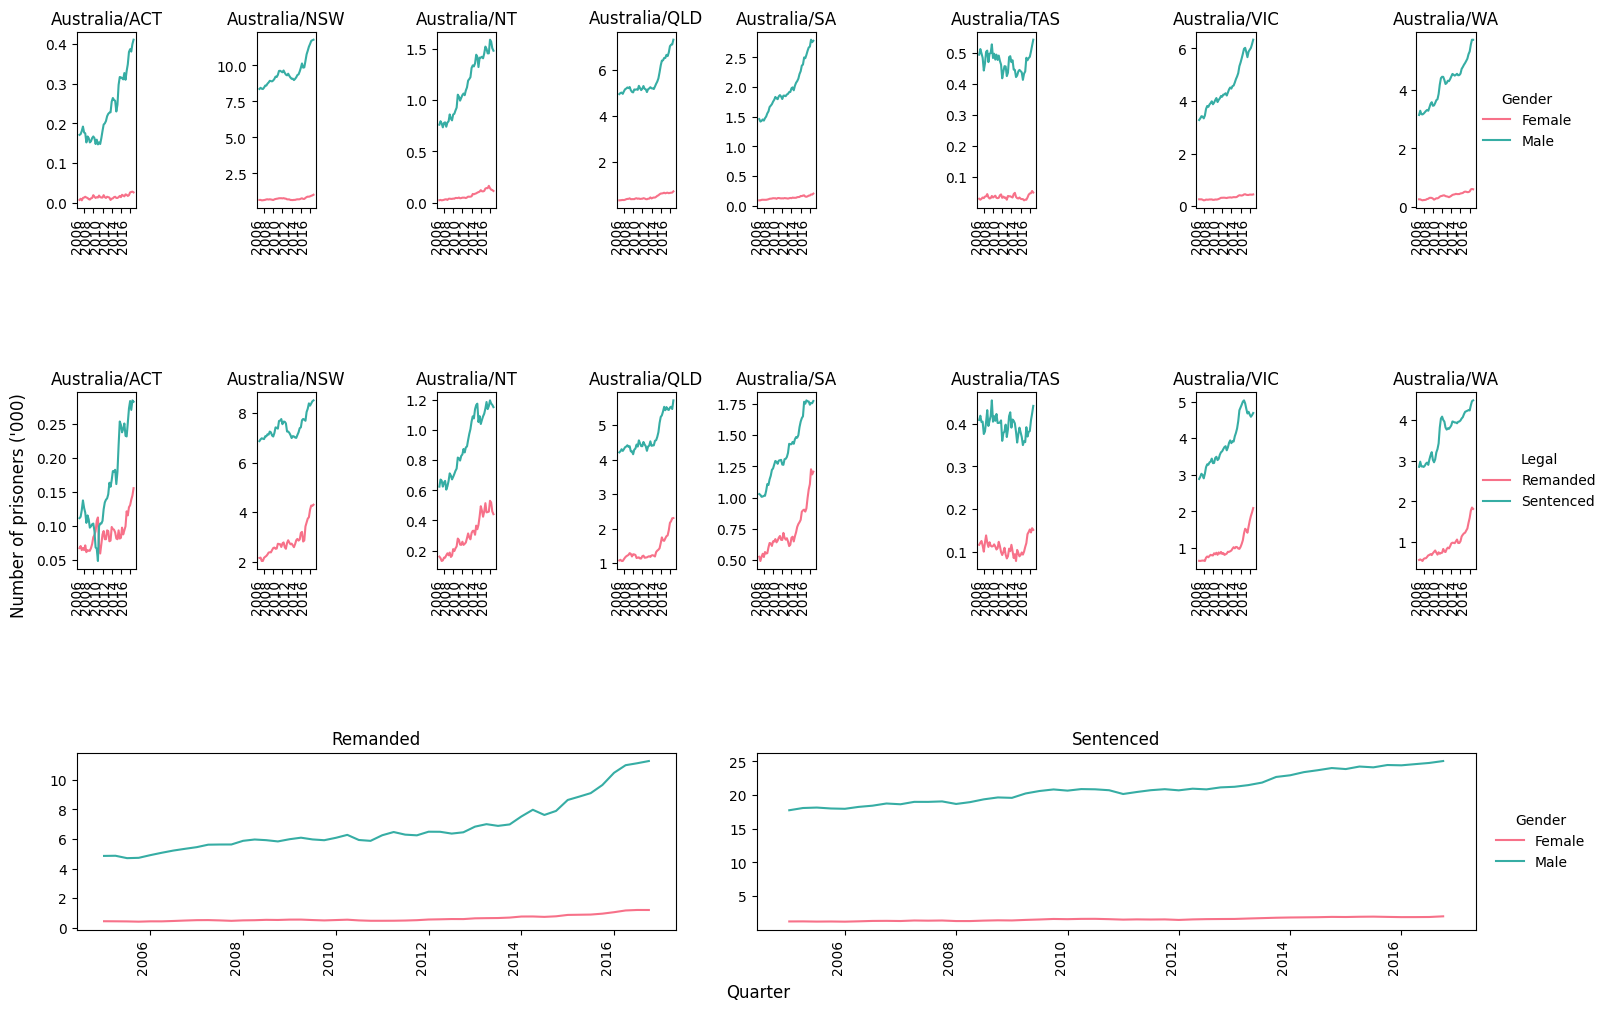

In [34]:
Y_df_plot = Y_df.assign(y=Y_df["y"] / 1e3).set_index("unique_id")
states = list(tags["Country/State"])
genders = prison["Gender"].unique()
legals = prison["Legal"].unique()

state_gender = [f"{state} Gender" for state in states]
state_legal = [f"{state} Legal" for state in states]
legal_gender = 4 * ["Remanded Gender"] + 4 * ["Sentenced Gender"]
mosaic = [state_gender, state_legal, legal_gender]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(16, 10),
    layout="constrained",
    gridspec_kw={"hspace": 0.35, "wspace": 0.2},
)

# Plot state/gender and state/legal
for key_column in ("Gender", "Legal"):
    for i, state in enumerate(states):
        labels = prison[key_column].unique()
        label_data = pd.concat([
            Y_df_plot.loc[f"{state}/{label}"]
            for label in labels
        ], keys=labels).reset_index(level=0)

        ax = axes[f"{state} {key_column}"]
        sns.lineplot(
            data=label_data, x="ds", y="y",
            hue="level_0", palette="husl", ax=ax,
        )
        ax.set(title=state, xlabel="", ylabel="")
        if i == len(states) - 1:
            ax.legend(
                title=key_column,
                bbox_to_anchor=(1.02, 0.5),
                loc="center left",
                borderaxespad=0,
                frameon=False,
            )
        else:
            ax.get_legend().remove()
        plt.setp(ax.get_xticklabels(), rotation=90, ha="right")

# Plot legal/gender
for i, legal in enumerate(legals):
    label_data = pd.concat([
        Y_df_plot.loc[f"Australia/{legal}/{gender}"]
        for gender in genders
    ], keys=genders).reset_index(level=0)

    ax = axes[f"{legal} Gender"]
    sns.lineplot(
        data=label_data, x="ds", y="y",
        hue="level_0", palette="husl", ax=ax,
    )
    ax.set(title=legal, xlabel="", ylabel="")
    if i == len(legals) - 1:
        ax.legend(
            title="Gender",
            bbox_to_anchor=(1.02, 0.5),
            loc="center left",
            borderaxespad=0,
            frameon=False,
        )
    else:
        ax.get_legend().remove()
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right")

fig.supylabel("Number of prisoners ('000)")
fig.supxlabel("Quarter", x=0.47)

fig;

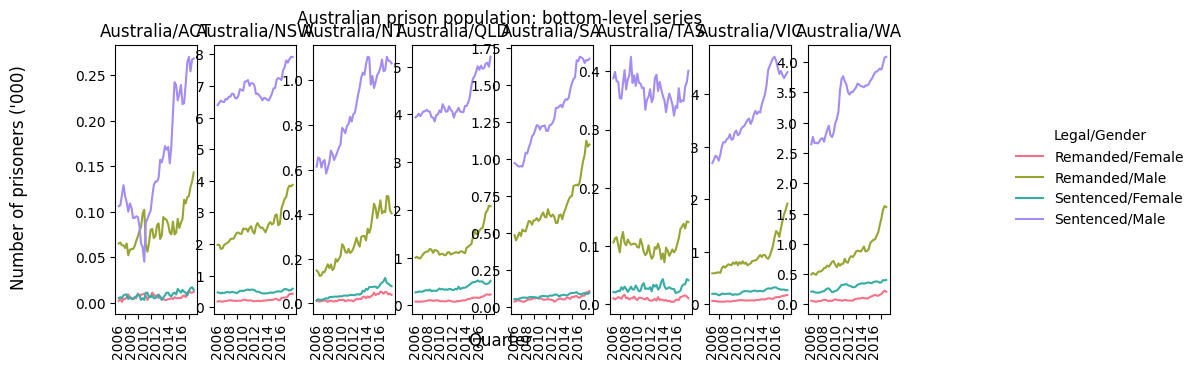

In [35]:
fig, axes = plt.subplots(1, len(states), figsize=(10, 3.5))
for i, (ax, state) in enumerate(zip(axes, states)):
    df = pd.concat([
        Y_df_plot.loc[f"{state}/{legal}/{gender}"].assign(
            key=f"{legal}/{gender}")
        for legal in legals
        for gender in genders
    ])
    sns.lineplot(data=df, x="ds", y="y",
        hue="key", palette="husl", ax=ax)
    ax.set(title=state, xlabel="", ylabel="")
    ax.get_legend().remove()
    plt.setp(ax.get_xticklabels(), rotation=90, ha='right')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Legal/Gender",
    bbox_to_anchor=(1.02, 0.5), loc='center left',
    borderaxespad=0, frameon=False)

fig.suptitle("Australian prison population: bottom-level series", x=.51)
fig.supxlabel("Quarter", x=.51)
fig.supylabel("Number of prisoners ('000)")
plt.show()